In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
print("=== TASK 1: Data Loading and Inspection ===")

url = "https://raw.githubusercontent.com/ravin508/ml-assessment-ravindra-hegde/main/data/q1_heart_disease.csv"
df = pd.read_csv(url)

print("Shape of dataset:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nFirst 5 rows:\n", df.head())


=== TASK 1: Data Loading and Inspection ===
Shape of dataset: (800, 12)

Data types:
 age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 rows:
    age  sex  chest_pain_type  resting_bp  cholesterol  fasting_bs  \
0   68    0  atypical_angina       142.0        399.0           0   
1   58    1      non_anginal       163.0        310.0           1   
2   44    1      non_anginal       128.0        175.0     

**Interpretation**:  
The dataset is almost perfectly balanced between the two classes (heart_disease = 0 and 1). This reduces the risk of models being biased toward the majority class. No immediate class imbalance handling is required.

=== TASK 2: Exploratory Data Analysis ===


C:\Users\Admin\AppData\Local\Temp\ipykernel_11212\264516775.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='heart_disease', data=df, palette=['lightblue', 'salmon'])


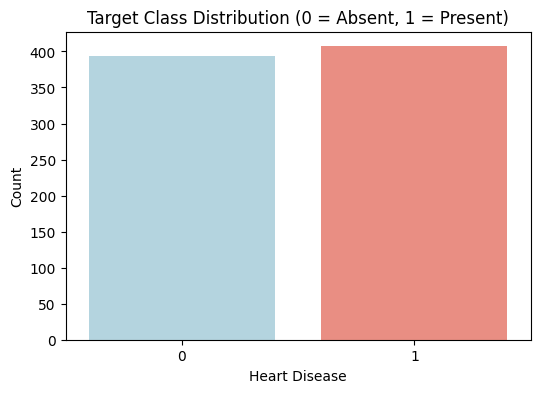

In [3]:
print("=== TASK 2: Exploratory Data Analysis ===")

# Plot 1: Target Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='heart_disease', data=df, palette=['lightblue', 'salmon'])
plt.title('Target Class Distribution (0 = Absent, 1 = Present)')
plt.xlabel('Heart Disease')
plt.ylabel('Count')
plt.savefig('target_distribution.png')
plt.show()

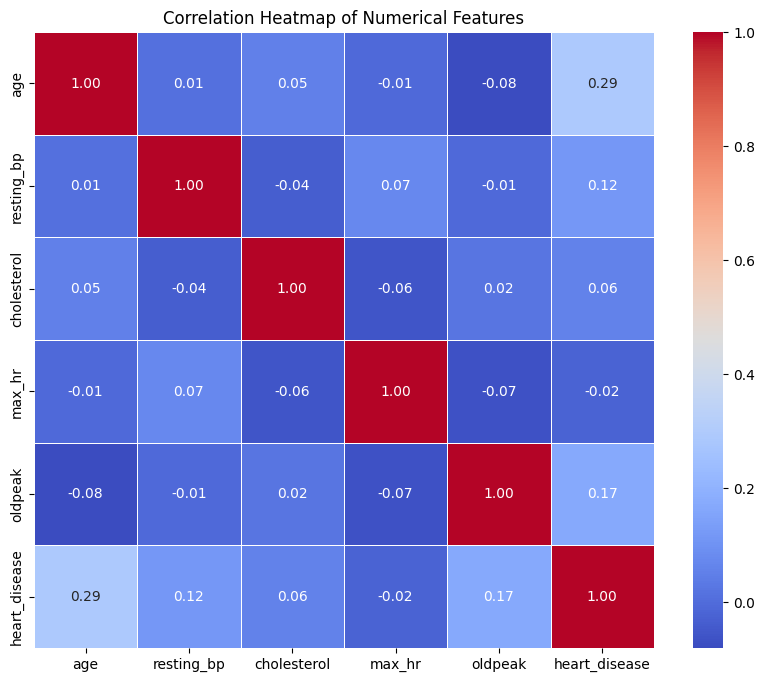

In [4]:
# === Additional EDA Visualizations ===

# Plot 2: Correlation Heatmap (Numerical Features)
plt.figure(figsize=(10, 8))
numerical_cols = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak', 'heart_disease']
corr_matrix = df[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.savefig('correlation_heatmap.png')
plt.show()

**Interpretation of Correlation Heatmap**:  
- Oldpeak shows the strongest positive correlation with heart_disease.  
- max_hr has a moderate negative correlation — higher maximum heart rate is associated with lower risk.  
- cholesterol and resting_bp show very weak correlations.  
This suggests that exercise-related features (oldpeak, max_hr) are more predictive than resting measurements in this dataset.

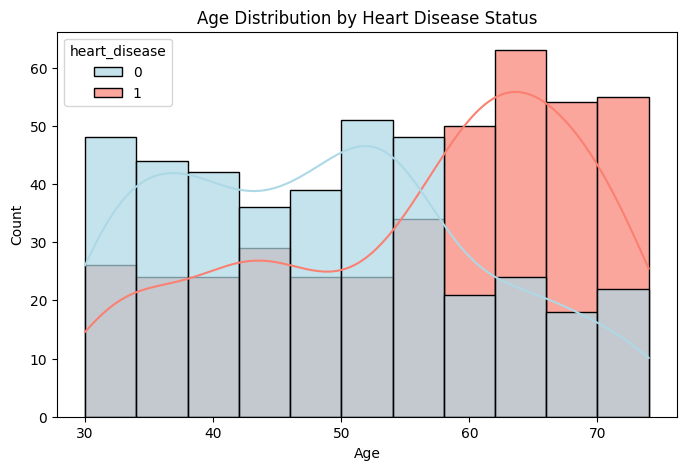

In [5]:
# Plot 3: Age Distribution by Heart Disease Status
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='heart_disease', kde=True,
             palette=['lightblue', 'salmon'], alpha=0.7)
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.savefig('age_distribution.png')
plt.show()



**Interpretation**:  
People with heart disease (class 1) tend to be slightly older on average than those without. The distribution for class 1 is shifted rightward, indicating age as a relevant risk factor. There is some overlap, so age alone is not a perfect separator but will likely be a useful feature for the models.

In [6]:
print("=== TASK 3: Data Preprocessing ===")

# Handle missing values using median imputation
df['resting_bp'] = df['resting_bp'].fillna(df['resting_bp'].median())
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())

print("Missing values after imputation:", df[['resting_bp', 'cholesterol']].isnull().sum().sum())

# One-hot encoding for categorical variables
df = pd.get_dummies(df, columns=['chest_pain_type', 'resting_ecg', 'st_slope'],
                    drop_first=True, dtype=float)

# Scale numerical features
scaler = StandardScaler()
scale_cols = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']
df[scale_cols] = scaler.fit_transform(df[scale_cols])

# Train-test split (stratified)
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training samples: {X_train.shape[0]} | Test samples: {X_test.shape[0]}")

=== TASK 3: Data Preprocessing ===
Missing values after imputation: 0
Training samples: 640 | Test samples: 160


In [7]:
print("=== TASK 4 & 5: Model Training and Evaluation ===")

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print(f"\n=== {name} Results ===")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

=== TASK 4 & 5: Model Training and Evaluation ===

Training Decision Tree...

=== Decision Tree Results ===
Confusion Matrix:
 [[56 23]
 [25 56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.71      0.70        79
           1       0.71      0.69      0.70        81

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160


Training Random Forest...

=== Random Forest Results ===
Confusion Matrix:
 [[61 18]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Training Gradient Boosting...

=== Gradient Boosting Re

### Best Performing Model (Untuned)

**Random Forest** is the best performing model among the three.

**Justification (based on metrics, not just accuracy)**:
- **Accuracy**: 79% (highest)
- **Macro Avg F1-score**: 0.79 (highest and well-balanced)
- **Precision & Recall**: Both classes have ~0.79–0.81, showing consistent performance on both positive and negative cases.
- Decision Tree performed the worst (~70% accuracy, lower F1), likely due to overfitting.
- Gradient Boosting (77%) is close but slightly behind Random Forest.

Random Forest's ensemble approach (bagging multiple trees) gives it better generalization on this dataset compared to a single Decision Tree and a slight edge over Gradient Boosting.

In [8]:
print("=== TASK 6: Hyperparameter Tuning on Gradient Boosting ===")

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation F1 Score:", round(grid_search.best_score_, 4))

# Evaluate the tuned model
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print("\n=== Tuned Gradient Boosting - Final Performance ===")
print(classification_report(y_test, y_pred_tuned))

=== TASK 6: Hyperparameter Tuning on Gradient Boosting ===
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best Cross-Validation F1 Score: 0.8192

=== Tuned Gradient Boosting - Final Performance ===
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



**Tuning Result**:  
The best parameters found were the default ones (learning_rate=0.1, max_depth=3, n_estimators=100). The tuned model gave identical performance to the baseline (77% accuracy, F1 ~0.77). This indicates that the default Gradient Boosting settings were already near-optimal for this dataset. Random Forest remains the strongest overall model.